<>:16: SyntaxWarning: invalid escape sequence '\P'
<>:16: SyntaxWarning: invalid escape sequence '\P'
C:\Users\nikit\AppData\Local\Temp\ipykernel_1800\421435955.py:16: SyntaxWarning: invalid escape sequence '\P'
  IMAGE_PATH = "D:\Programming-at-SUSU\BasicOfCV\materials\lenna.jpg"


Text(0.5, 1.0, 'Histogram')

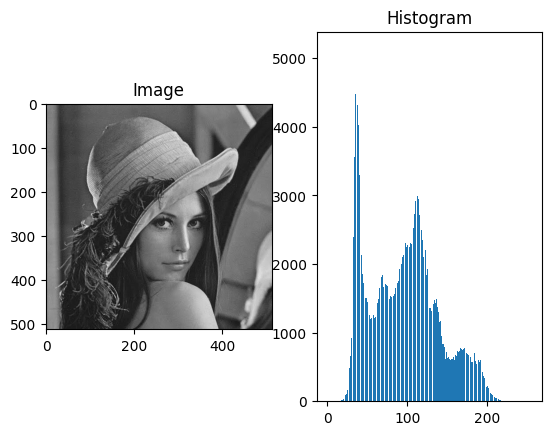

In [2]:
import cv2  
import matplotlib.pyplot as plt  
import numpy as np  
import os  

#Пример 1
"""
Рассмотрим пример с вычислением гистограммы изображения. Для 
демонстрации вычисления гистограммы понадобится изображение. 
Убедитесь, что IMAGE_PATH содержит путь до существующего 
изображения.  

Гистограмма показывает интенсивность яркости пикселей, большинство преобладает темного, т.е. если смотреть диапазон [0;255],
где 0 - темный, а 255 - белый (яркий) цвет, то на [30;50] - много пискелей
"""
IMAGE_PATH = "D:\Programming-at-SUSU\BasicOfCV\materials\lenna.jpg" 
assert os.path.exists(IMAGE_PATH) #Проверка утверждения - правильно указан путь

# Вычислим и отрисуем гистограмму для черно-белого изображения. 
image = cv2.imread(IMAGE_PATH) 
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 
histogram = cv2.calcHist([gray_image], [0], None, [256], [0, 256]) 
histogram = np.squeeze(histogram) 
histogram_x_range = list(range(len(histogram))) 
# plot  
fig, ax = plt.subplots(1, 2) 
ax[0].imshow(gray_image, cmap="gray") 
ax[0].set_title("Image") 
ax[1].bar(x=histogram_x_range, height=histogram) 
ax[1].set_title("Histogram") 

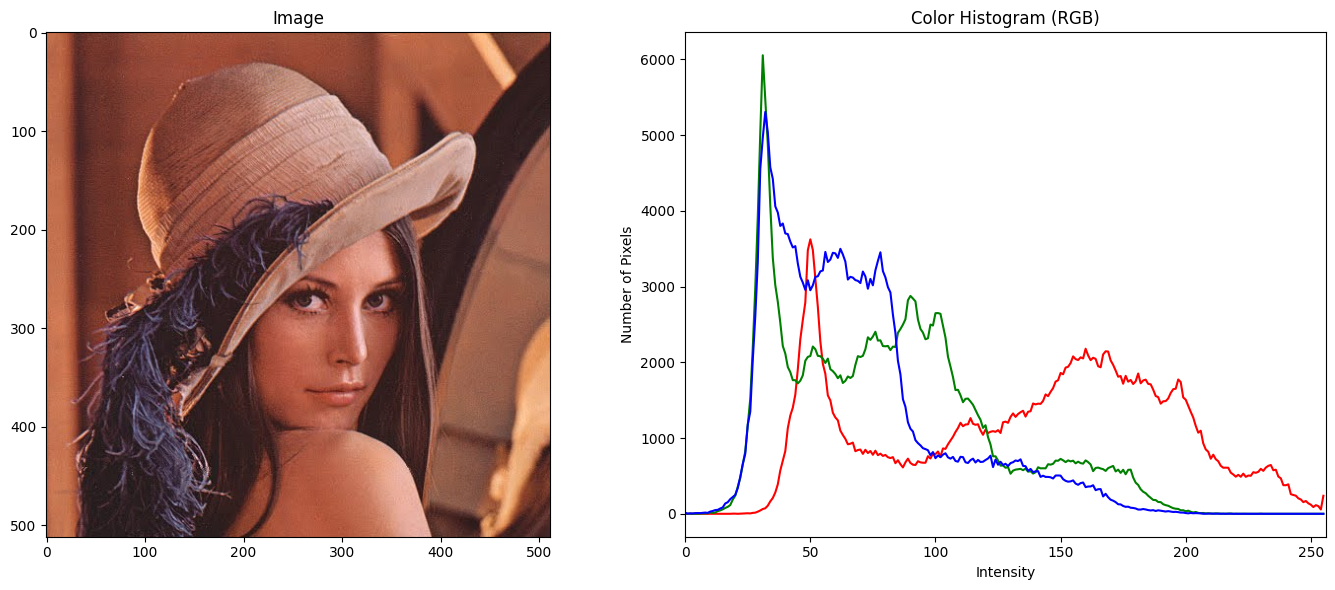

In [ ]:
"""
Собственный пример - дополнительно:
Хочу увидеть на гистограмме - интенсивность яркости каждого канала R, G, B
"""

image2 = cv2.imread(IMAGE_PATH)
image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)  # переводим в RGB для корректных цветов

colors = ('red', 'green', 'blue')

fig, ax = plt.subplots(1, 2, figsize=(14, 6)) 
ax[0].imshow(image2) 
ax[0].set_title("Image") 
# ax[0].axis("off")

# Рисуем гистограмму для каждого канала
for i, color in enumerate(colors):
    hist = cv2.calcHist([image2], [i], None, [256], [0, 256])
    ax[1].plot(hist, color=color)

ax[1].set_xlim([0, 256])
ax[1].set_title("Color Histogram (RGB)")
ax[1].set_xlabel("Intensity")
ax[1].set_ylabel("Number of Pixels")


plt.tight_layout() # Чтобы графики не перекрывали друг друга
plt.show()

In [23]:
"""
Дополнительно: 
Для самостоятельного изучения: 
1)изучить функцию np.squeeze; 
2)изменить количество бинов гистограммы. 
"""

'\nДополнительно: \nДля самостоятельного изучения: \n1)изучить функцию np.squeeze; \n2)изменить количество бинов гистограммы. \n'

In [24]:
# Для пункта 1:
# В прошлом примере:
histogram = cv2.calcHist([gray_image], [0], None, [256], [0, 256])
print(histogram.shape)  # будет (256, 1)
histogram = np.squeeze(histogram)
print(histogram.shape)  # теперь (256,)
print()

# Создадим массив размером (1, 3, 1)
arr = np.array([[[1], [2], [3]]])
print("Исходный массив:")
print(arr)
print("Shape:", arr.shape)
print()

# Применим np.squeeze()
squeezed_arr = np.squeeze(arr)
print("После np.squeeze():")
print(squeezed_arr)
print("Shape:", squeezed_arr.shape)
print()

# Для наглядности: можно поэтапно убрать оси
squeezed_arr_2 = np.squeeze(arr, axis=0)  # убираем первую ось
print("После np.squeeze с axis=0:")
print(squeezed_arr_2)
print("Shape:", squeezed_arr_2.shape)
print()

squeezed_arr_3 = np.squeeze(arr, axis=2)  # убираем последнюю ось
print("После np.squeeze с axis=2:")
print(squeezed_arr_3)
print("Shape:", squeezed_arr_3.shape)

(256, 1)
(256,)

Исходный массив:
[[[1]
  [2]
  [3]]]
Shape: (1, 3, 1)

После np.squeeze():
[1 2 3]
Shape: (3,)

После np.squeeze с axis=0:
[[1]
 [2]
 [3]]
Shape: (3, 1)

После np.squeeze с axis=2:
[[1 2 3]]
Shape: (1, 3)


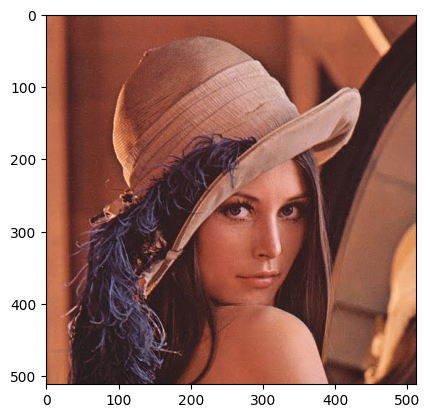

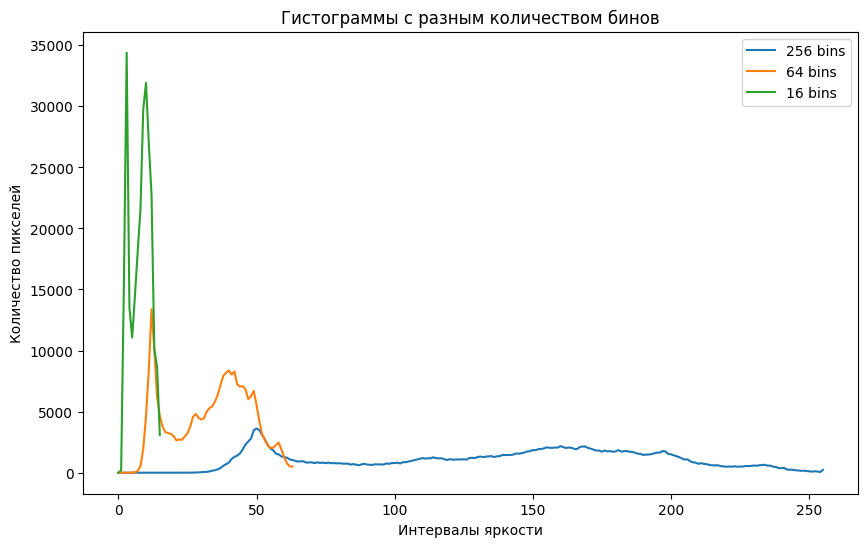

In [ ]:
# Для 2 пункта:
"""
"Бины" (bins) — это количество интервалов, на которые делятся значения для гистограммы.
Ранее было в примере 256  бинов, т.е. по одному на каждое значение яркости.
Но можно сделать, например, 32 бина — тогда гистограмма будет сглаженной.
"""
import cv2
import matplotlib.pyplot as plt

image = cv2.imread(IMAGE_PATH, cv2.IMREAD_COLOR_RGB)
plt.imshow(image)
# Считаем гистограмму с разным количеством бинов
bins_list = [256, 64, 16]

plt.figure(figsize=(10, 6))

for bins in bins_list:
    hist = cv2.calcHist([image], [0], None, [bins], [0, 256])
    hist = np.squeeze(hist)
    plt.plot(hist, label=f"{bins} bins")

plt.legend()
plt.title("Гистограммы с разным количеством бинов")
plt.xlabel("Интервалы яркости")
plt.ylabel("Количество пикселей")
plt.show()


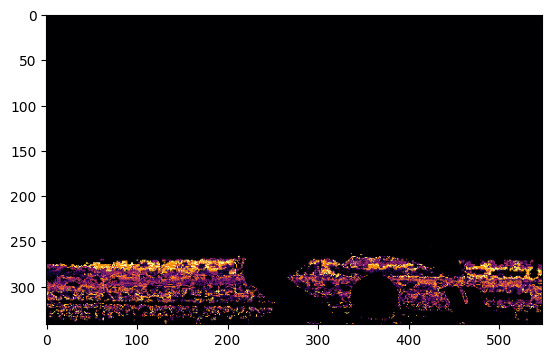

In [5]:
"""
Рассмотрим решение histigram backrpojection для сегментации объекта. 
Для этого понадобятся: 
1)тестовое изображение, на котором будем искать объект; 
2)содержащее объект изображение, которое будет использоваться для подсчета распределения цветов объекта (будем называть его обучающее изображение).
Убедитесь, что необходимые изображения существуют.
"""
 
TARGET_IMAGE_PATH = r"D:\Programming-at-SUSU\BasicOfCV\materials\full_image.jpg" 
TRAIN_IMAGE_PATH = r"D:\Programming-at-SUSU\BasicOfCV\materials\train_crop.jpg" 
assert os.path.exists(TARGET_IMAGE_PATH) 
assert os.path.exists(TRAIN_IMAGE_PATH) 

"""
Сегментация будет происходить на основе первых двух каналов hsv 
пространства, но нам также понадобится rgb изображения для 
визуализации, введем вспомогательные функции для считывания 
изображений. 
"""
def read_rgb_from_file(file: str) -> np.ndarray: 
    """Reads image and converts it to rgb""" 
    image = cv2.imread(file) 
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 
    return image 
def read_hsv_from_file(file: str) -> np.ndarray: 
    """Reads image and converts it to hsv""" 
    image = cv2.imread(file) 
    image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV) 
    return image 

"""Решим задачу histogram backprojection."""
train_hsv = read_hsv_from_file(TRAIN_IMAGE_PATH) 
train_image_h, train_image_w = train_hsv.shape[:2] 
train_image_area = train_image_h * train_image_w 
full_image_hsv = read_hsv_from_file(TARGET_IMAGE_PATH) 

# гистограмма по каналам Hue (0) и Saturation (1)
# Построение гистограммы: 180 бинов для Hue, 256 бинов для Saturation
train_imagehist = cv2.calcHist([train_hsv], [0, 1], None, [180, 256], [0, 180, 0, 256]) 
# Обратное проецирование - это процесс, при котором для каждого пикселя целевого изображения вычисляется, насколько его цвет соответствует цветовой модели объекта.
backprojection_map = cv2.calcBackProject([full_image_hsv], [0, 1], train_imagehist, [0, 180, 0, 256], scale=1)  
# Переведем эти значения в вероятности 
backprojection_map = backprojection_map.astype(np.float32) 
backprojection_map /= train_image_area 

"""
После обратного преобразования гистограммы переменная 
backprojection_map 
отражает количество пикселей целевого 
изображения с такими же значениями hue и saturation, как у обучающего 
изображения. Далее эти значения переводятся в вероятности. 
Визуализируем получившиеся вероятности. 
"""
plt.imshow(backprojection_map, cmap="inferno") 

'\nВ правой части - результат:\nЦветные области - то, что алгоритм посчитал "похожим на объект"\nЧерные области - то, что отсеялось как "фон"\nПо сути - это предварительная сегментация.\n\nЧто означает порог (threshold = 0.001):\nПорог - это "степень уверенности" алгоритма:\nНизкий порог (0.0001) - "Покажи всё, что хоть немного похоже"\nБольше шума, но меньше шансов пропустить объект\nВысокий порог (0.01) - "Покажи только то, что очень похоже"\nМеньше шума, но можно потерять части объекта\n'

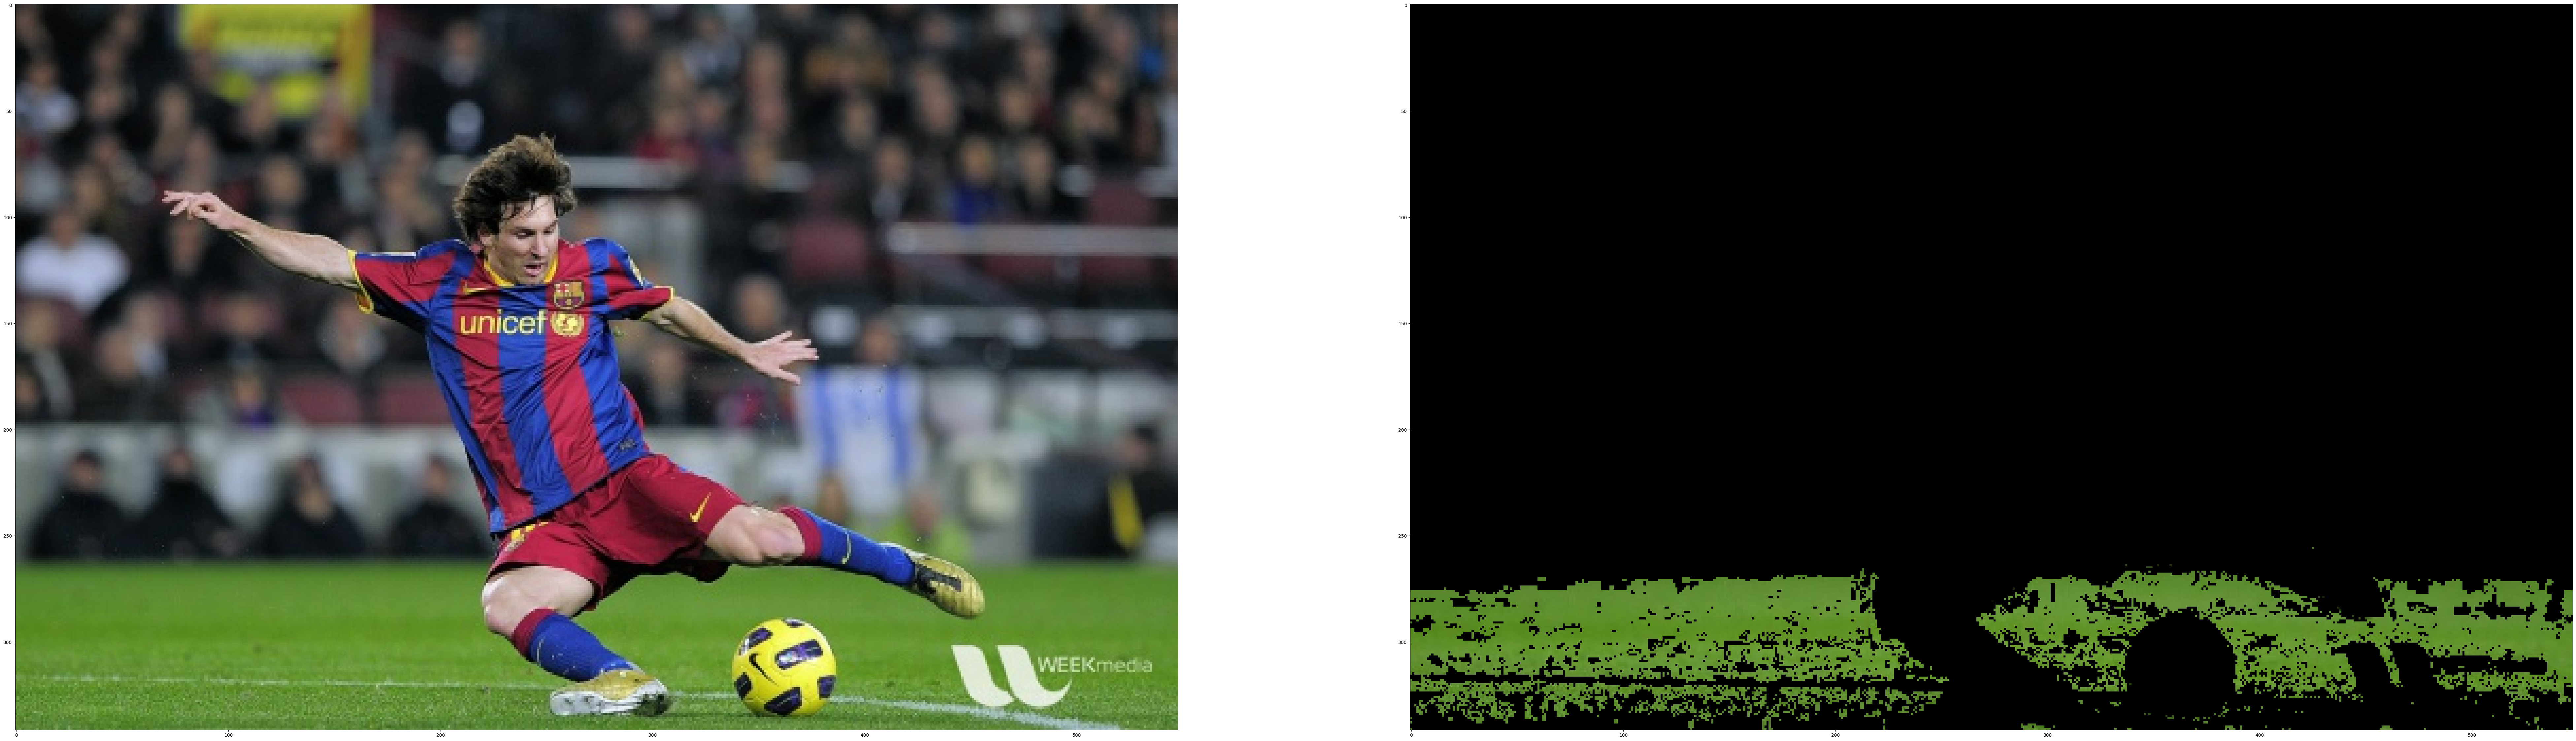

In [6]:
"""
Отрисуем оригинальное изображение и получившуюся маску. 
Следует обратить внимание на значение переменной threshold и 
проверить, как изменится маска при различных ее значениях.
"""

threshold = 0.001
full_image_rgb = read_rgb_from_file(TARGET_IMAGE_PATH) 
mask = backprojection_map > threshold 
masked_image = np.copy(full_image_rgb) 
masked_image[mask == 0] = [0, 0, 0] 
fig, (image1_axes, image2_axes) = plt.subplots(1, 2, figsize=(100, 50)) 
image1_axes.imshow(full_image_rgb) 
image2_axes.imshow(masked_image) 

"""
В правой части - результат:
Цветные области - то, что алгоритм посчитал "похожим на объект"
Черные области - то, что отсеялось как "фон"
По сути - это предварительная сегментация.

Что означает порог (threshold = 0.001):
Порог - это "степень уверенности" алгоритма:
Низкий порог (0.0001) - "Покажи всё, что хоть немного похоже"
Больше шума, но меньше шансов пропустить объект
Высокий порог (0.01) - "Покажи только то, что очень похоже"
Меньше шума, но можно потерять части объекта
"""

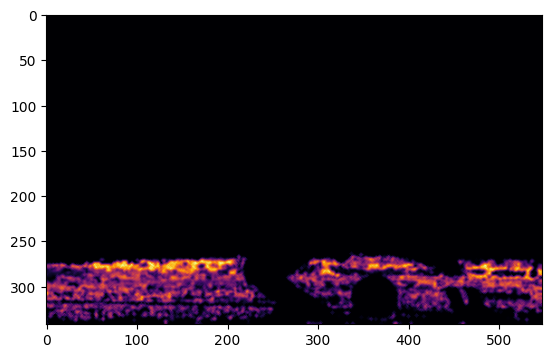

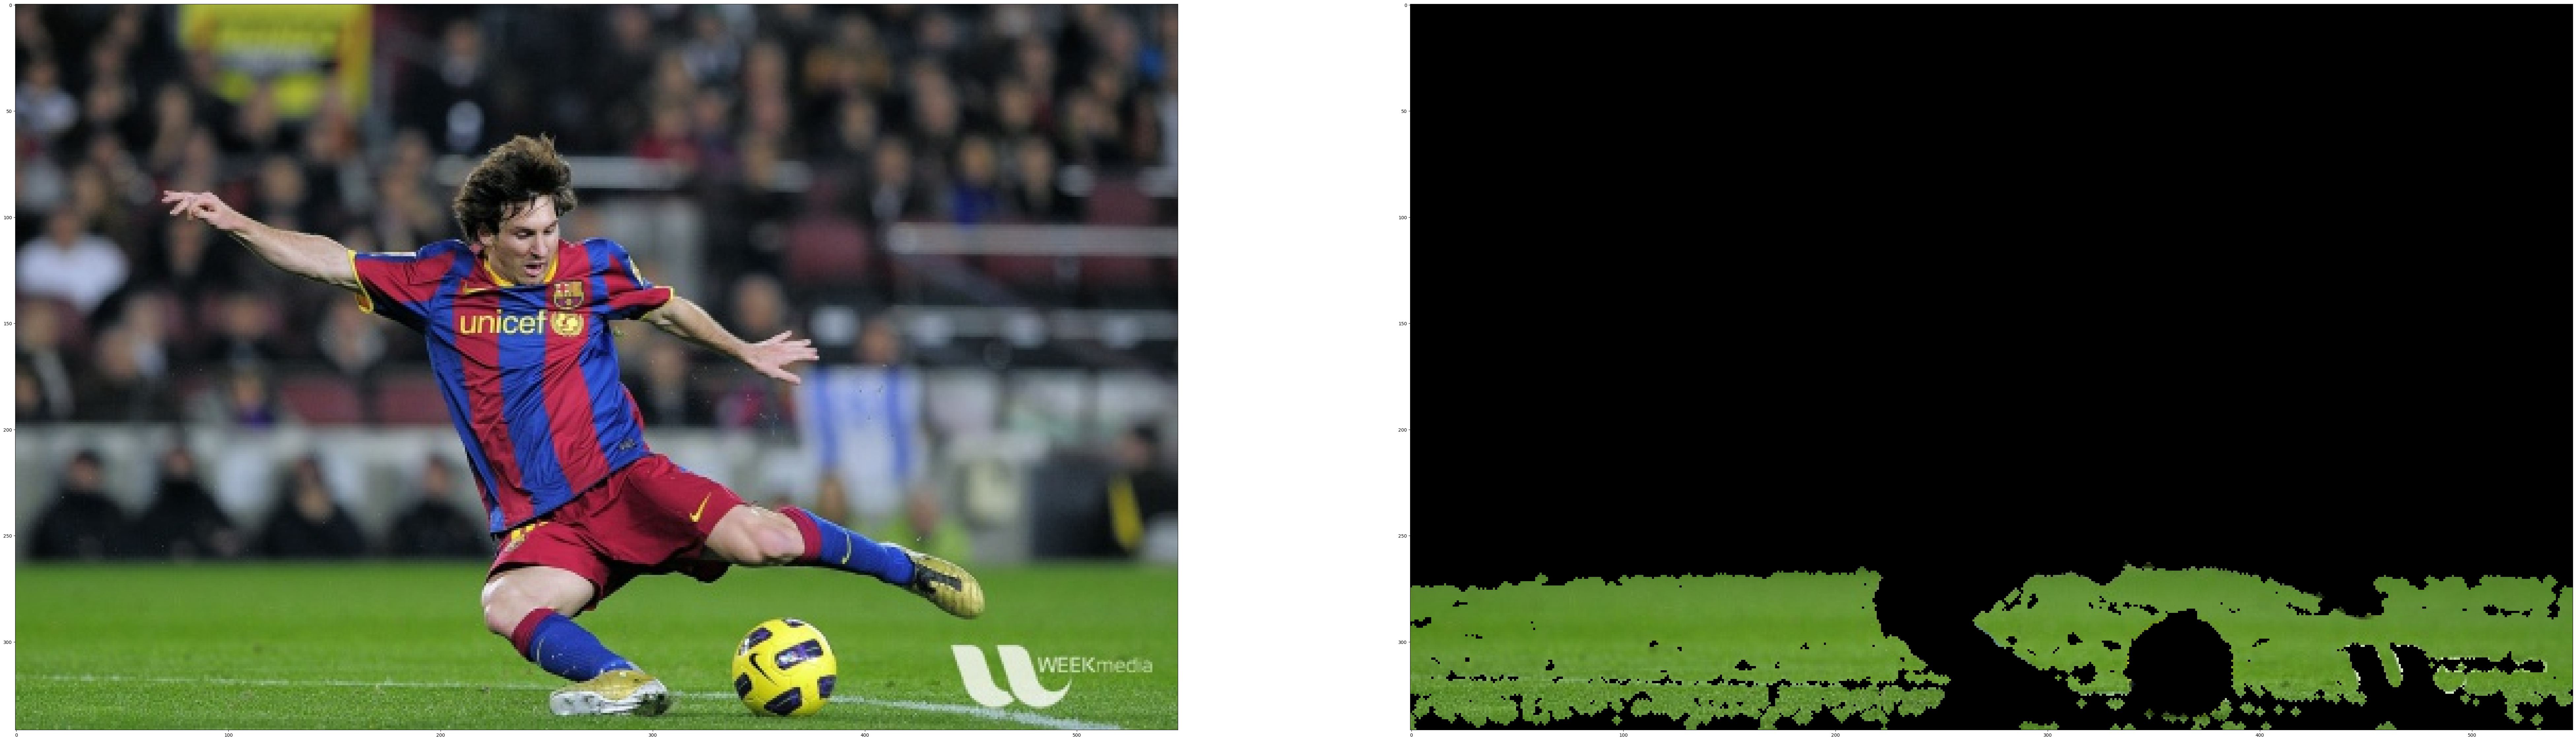

In [7]:
"""
 Рассмотрим пример сглаживания маски с помощью билатерального 
фильтра, сначала зададим все необходимые параметры для его 
применения: 
− neighborhood_diameter - диаметр окрестности вокруг пикселя, 
которая будет использоваться при применении фильтра 
− sigmaColor - параметр контролирующий насколько далекие в 
цветовом пространстве пиксели могут оказывать друг на друга 
влияние при применении фильтра. 
− sigmaSpace - параметр контролирующий насколько далекие (в 
терминах евклидова расстояния на изображении) пиксели могут 
оказывать друг на друга влияние при применении фильтра. 
"""
"""
Мое дополнение:
Билатерального фильтра - это "умное" размытие, которое:
Сохраняет четкие границы (края объектов)
Сглаживает шумы внутри объектов
Учитывает как цветовую близость, так и пространственную близость пикселей
"""
"""
Что это: Диаметр окрестности вокруг каждого пикселя
Объяснение: Фильтр будет рассматривать пиксели в круге диаметром 5 пикселей вокруг текущего пикселя. Больше значение = большее размытие, но медленнее вычисления.
""" 
neighborhood_diameter = 5 

"""
Что это: "Цветовая терпимость"
Объяснение: Определяет, насколько разные по цвету пиксели могут влиять друг на друга:
Малое значение (0.35): только очень похожие по цвету пиксели влияют друг на друга
Большое значение: даже сильно разные цвета могут влиять
"""
sigmaColor = 0.35 

"""
Что это: "Пространственная терпимость"
Объяснение: Определяет, насколько далекие пиксели могут влиять:
Большое значение (100): даже далекие пиксели сильно влияют
Малое значение: только ближайшие соседи имеют влияние
"""
sigmaSpace = 100 

"""Теперь применим фильтр с выбранными параметрами и визуализируем результат. """
threshold = 0.001 
mask = cv2.bilateralFilter(backprojection_map, neighborhood_diameter, 
sigmaColor, sigmaSpace) 
plt.imshow(mask, cmap="inferno")

plt.show() 
mask = mask > threshold 
masked_image = np.copy(full_image_rgb) 
masked_image[mask == 0] = [0, 0, 0] 
fig, (image1_axes, image2_axes) = plt.subplots(1, 2, figsize=(100, 50)) 
image1_axes.imshow(full_image_rgb) 
image2_axes.imshow(masked_image)  

In [8]:
"""
 Далее рассмотрим сегментацию с использованием суперпикселей, 
будем использовать алгоритм SLIC. Ниже приведены основные 
константы, определяющие работу алгоритма: желаемый размер блока из 
суперпикселей, количество итераций, размер суперпикселей, которые 
будут объединены с другими на этапе постобработки. 
"""
block_size_pixels = 20 
iter_num = 10 
enforce_size_percents = 10 
image = cv2.imread(IMAGE_PATH) 
# Для суперпиксельной сегментации переведем изображение в пространство LAB 
image_LAB = cv2.cvtColor(image, cv2.COLOR_BGR2LAB) 
slic_obj = cv2.ximgproc.createSuperpixelSLIC( image=image_LAB, algorithm=cv2.ximgproc.SLIC, region_size=block_size_pixels, ) 
slic_obj.iterate(iter_num) 
slic_obj.enforceLabelConnectivity(enforce_size_percents)
"""
Теперь у нас есть объект, содержащий суперпиксельную 
сегментацию, доступ к ней происходит с помощью метода getLabels. В 
результате получим массив, в котором каждому пикселю соотвествует 
число, обозначающее номер суперпикселя, к которому он принадлежит. 
Число суперпикселей getNumberOfSuperpixels.
"""
label_map = slic_obj.getLabels() 
superpixels_num = slic_obj.getNumberOfSuperpixels() 
print(label_map) 
print(superpixels_num) 

[[  0   0   0 ...  27  27  27]
 [  0   0   0 ...  27  27  27]
 [  0   0   0 ...  27  27  27]
 ...
 [779 779 779 ... 818 818 818]
 [779 779 779 ... 818 818 818]
 [779 779 779 ... 818 818 818]]
820


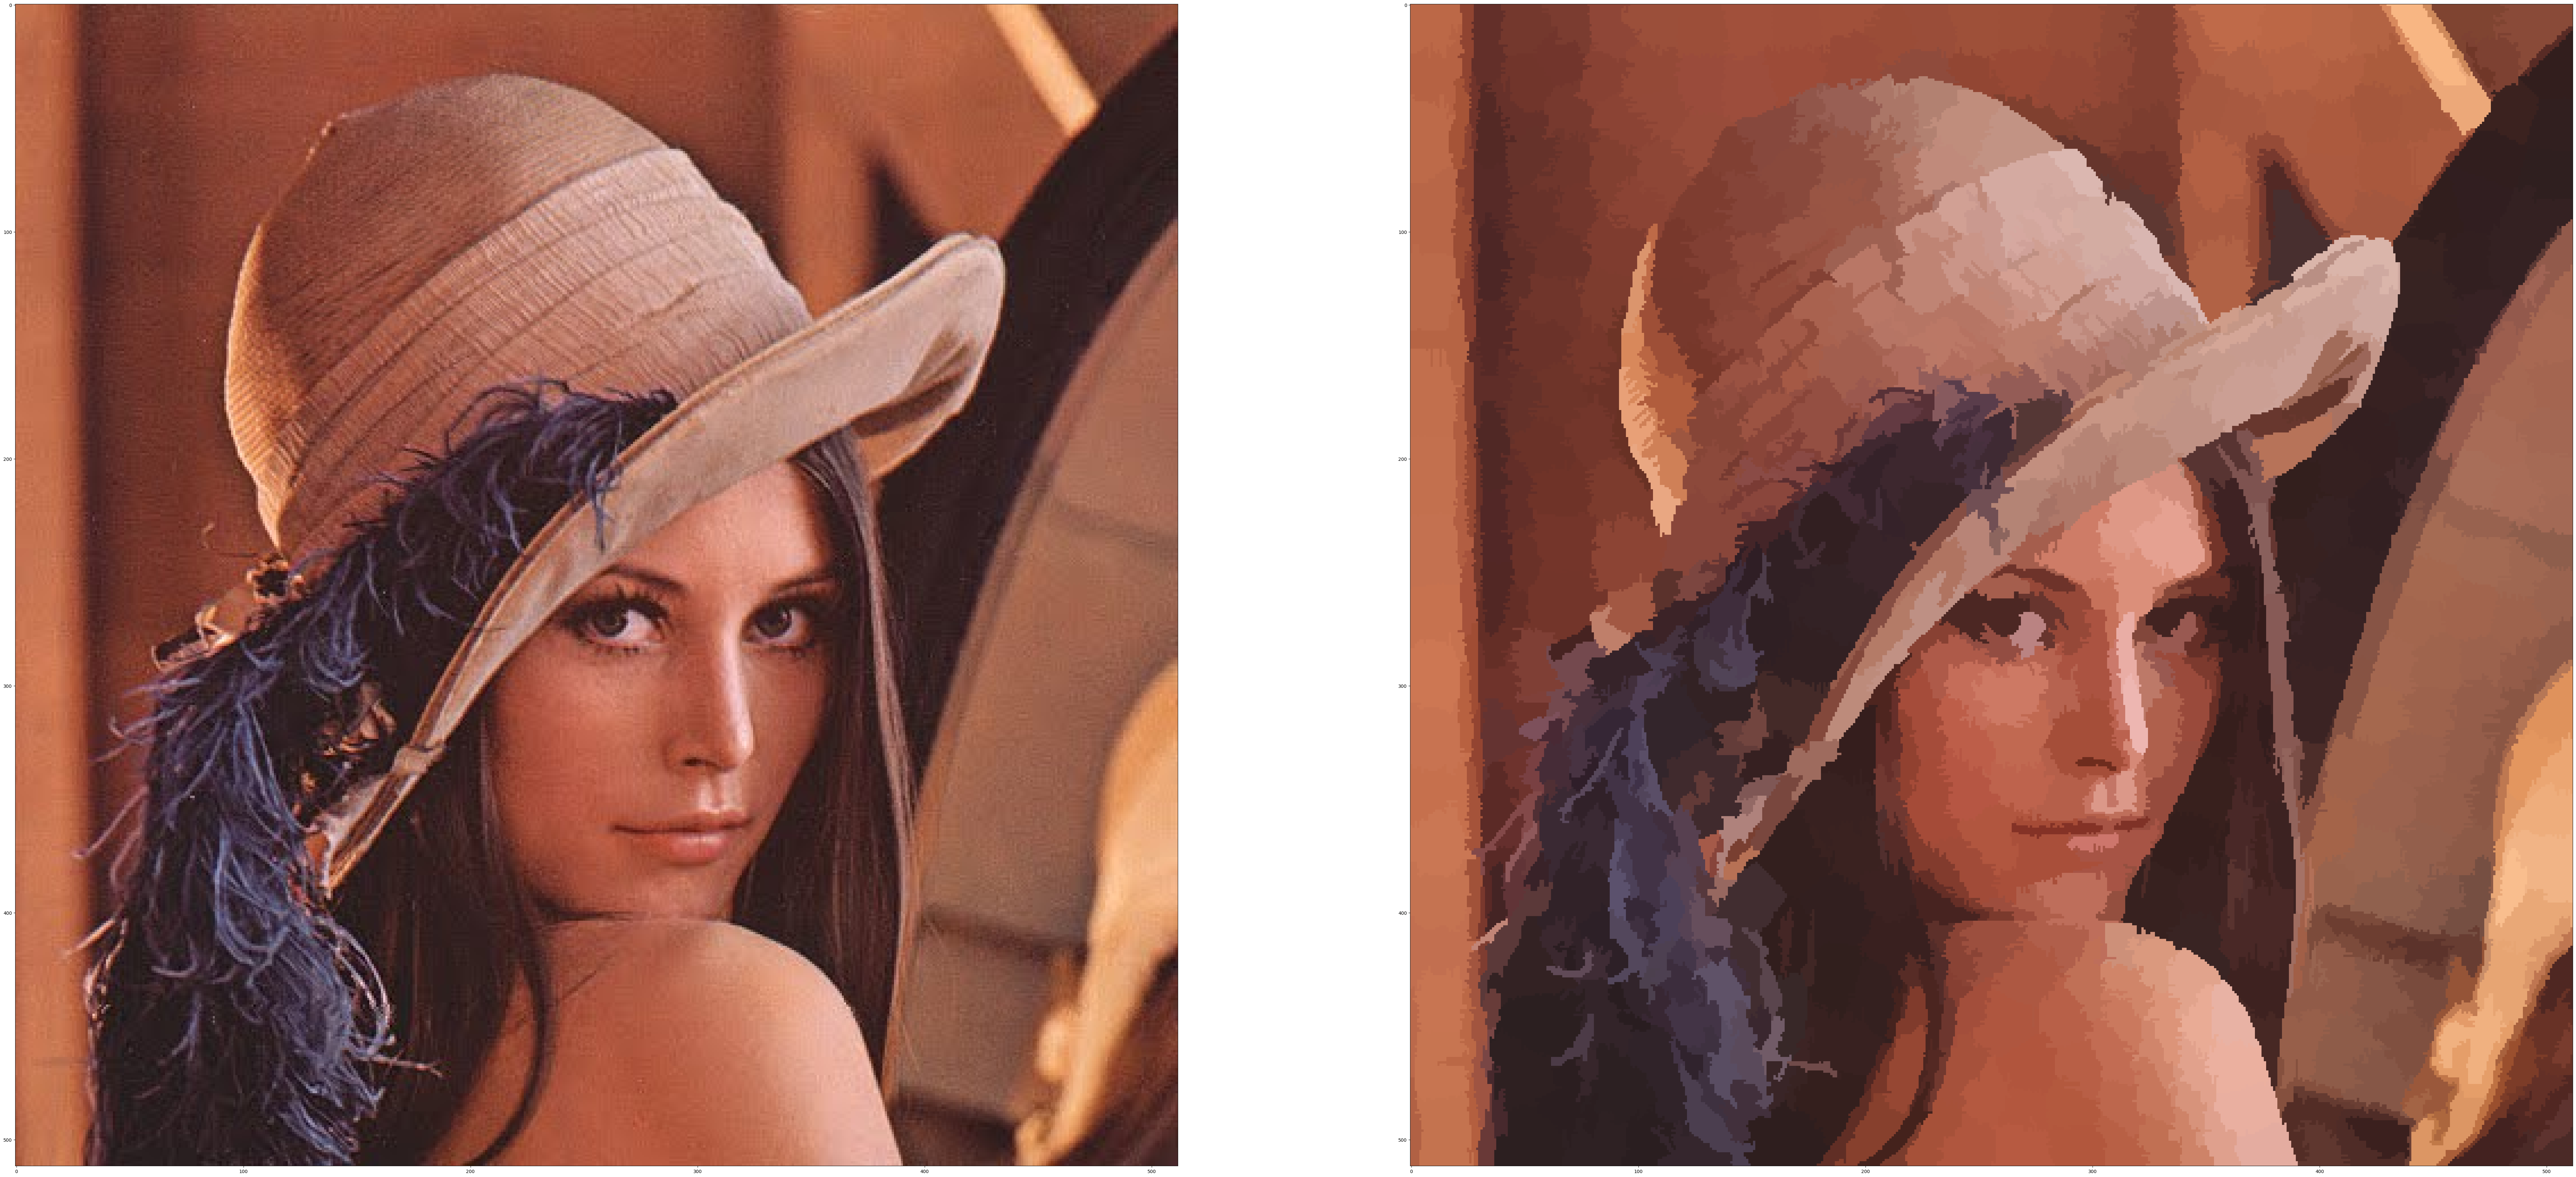

In [9]:
"""
В качестве примера работы с суперпиксельной сегментацией решим 
следующую задачу: заменим все пиксели средним цветом 
соответствующего суперпикселя. 
"""
superpixel_processed_image = np.zeros(image_LAB.shape, dtype=image.dtype) 
image_RGB = read_rgb_from_file(IMAGE_PATH) 
for superpixel_num in range(superpixels_num): 
    superpixel_mask = label_map == superpixel_num 
    original_image_values = image_RGB[superpixel_mask] 
    mean_superpxixel_color = np.mean(original_image_values, axis=0).astype(image.dtype) 
    superpixel_processed_image[superpixel_mask] = mean_superpxixel_color 
fig, (image1_axes, image2_axes) = plt.subplots(1, 2, figsize=(100, 50)) 
image1_axes.imshow(image_RGB) 
image2_axes.imshow(superpixel_processed_image) 

In [10]:
"""
Для самостоятельного изучения: 
− np.squeeze 
− np.expand_dims 
"""

# Ранее показывал пример с np.squeeze выше
# Тогда как, np.expand_dims - добавляет ось в указанное место

arr = np.array([[[1], [2], [3]]])
print("Исходный массив:")
print(arr)
print("Shape:", arr.shape)
print()

# Применим np.squeeze()
squeezed_arr = np.squeeze(arr)
print("После np.squeeze():")
print(squeezed_arr)
print("Shape:", squeezed_arr.shape)
print()

# Массив shape (3,)
c = np.array([1, 2, 3])
print(c.shape)  # (3,)

# Добавим ось в начало (axis=0)
d = np.expand_dims(c, axis=0)
print(d.shape)  # (1, 3)

# Добавим ось в конец (axis=1)
e = np.expand_dims(c, axis=1)
print(e.shape)  # (3, 1)

Исходный массив:
[[[1]
  [2]
  [3]]]
Shape: (1, 3, 1)

После np.squeeze():
[1 2 3]
Shape: (3,)

(3,)
(1, 3)
(3, 1)
